# **Demo 03: Building a Reactive Agent Workflow with LangGraph and Tavily**

**Objective:** To demonstrate how to build a reactive AI agent using the LangGraph framework integrated with LangChain’s Tavily search tool. This demo guides learners through creating a react-style agent using create_react_agent(), connecting it to a real-time web search function, and invoking the agent to respond dynamically to user queries. The focus is on showcasing how LangGraph enables modular, tool-enhanced agent workflows for tasks that require external information retrieval and context-aware decision-making

**Prerequisites:** Tavily key, OpenAI API key 

**Tools required:** Python

**Scenario:** : A product lead at a fintech startup wants to monitor global developments in real-time fraud detection methods for UPI systems. The manual process of tracking cybersecurity advancements and regulatory changes is inefficient and prone to oversight. The goal is to automate this workflow using LangGraph, where an agent uses a search tool to gather the latest research and another agent validates and summarizes the findings for internal teams.

In [ ]:
# Step 1: Install required libraries
!pip install langgraph langchain-openai langchain-tavily tavily-python


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/786.8 kB ? eta -:--:--
   ---------------------------------------- 786.8/786.8 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.99.6
    Uninstalling openai-1.99.6:
      Successfully uninstalled openai-1.99.6


In [ ]:

import os

# ---- Azure APIM credentials ----
os.environ["OPENAI_API_KEY"] = "2ABecnfxzhRg4M5D6pBKiqxXVhmGB2WvQ0aYKkbTCPsj0JLKsZPfJQQJ99BDAC77bzfXJ3w3AAABACOGi3sC"
os.environ["OPENAI_API_BASE"] = "https://openai-api-management-gw.azure-api.net"  # APIM base
os.environ["OPENAI_API_VERSION"] = "2025-01-01-preview"
os.environ["AZURE_DEPLOYMENT"] = "gpt-4o-mini"   # your deployment name

# ---- Tavily Key ----
os.environ["TAVILY_API_KEY"] = "<Travily key>" # Use your own Tavily key


In [ ]:
# Create the LLM object (Azure OpenAI via langchain-openai)

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    deployment_name=os.environ["AZURE_DEPLOYMENT"],   # gpt-4o-mini
    api_key=os.environ["OPENAI_API_KEY"],
    azure_endpoint=os.environ["OPENAI_API_BASE"],     # APIM gateway endpoint
    api_version=os.environ["OPENAI_API_VERSION"],
    temperature=0.3
)


In [ ]:
# Build Tavily Search Tool

from langchain_tavily import TavilySearch
from langchain.tools import tool

@tool
def search_tool(query: str):
    """Use this tool to search the web via Tavily API"""
    tavily_search_tool = TavilySearch(max_results=3)
    result = tavily_search_tool.invoke(query)
    return result


In [ ]:
# Create a Reactive Agent with LangGraph and attach the Tavily tool

from langgraph.prebuilt import create_react_agent

agent = create_react_agent(model=llm, tools=[search_tool])


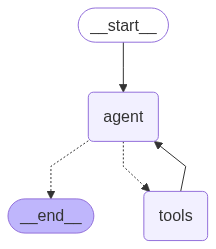

In [ ]:
# Visualize the agent graph
agent

In [ ]:
# Execute the agent WITH the search tool
state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What are the latest fraud detection methods in UPI systems?"}
    ]
})

print("\n[With Tavily Search Tool]:\n", state)


In [ ]:
# Execute the agent WITHOUT the search tool (pure LLM reasoning)
state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is 2 + 3?"}
    ]
})

print("\n[Without Tool]:\n", state)


{'messages': [HumanMessage(content='who is presidet of usa', additional_kwargs={}, response_metadata={}, id='8e137d18-f415-44ac-b97e-30fbe2bc9d03'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_J9NKHgHVkpyLt8Wr3VauuPw5', 'function': {'arguments': '{"query":"current president of USA"}', 'name': 'search_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 51, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62a23a81ef', 'id': 'chatcmpl-C4lmAdrpHd5H4jhJQpagVGJQviqwK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a87cacd5-4c74-4a82-b593-91c6f9939d75-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'current

#### By following these steps, you have successfully built a reactive AI agent with LangGraph, integrated LangChain’s Tavily search, created it via create_react_agent(), connected real-time web search, and invoked it to respond dynamically to user queries—showcasing LangGraph’s modular, tool-enhanced workflows for external retrieval and context-aware decision-making.